# IT25102835 — Correlation feature selection
Wanigasekara W.M.T.S.B. | 2026-Y2-S1-KU-28

In [ ]:
## 1. Load the data
column_names.csv contains the 43 field names in order; it contains no hidden preprocessing code.

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Local: open Jupyter from the extracted project folder.
# Colab: replace this path with your extracted folder in Google Drive.
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
columns = pd.read_csv(ROOT / 'data/column_names.csv')['column_name'].tolist()
train = pd.read_csv(ROOT / 'data/raw/KDDTrain+.txt', names=columns)
test = pd.read_csv(ROOT / 'data/raw/KDDTest+.txt', names=columns)
FIG = ROOT / 'results/eda_visualizations'
OUT = ROOT / 'results/outputs'
print('Train:', train.shape, 'Test:', test.shape)
display(train.head())


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


Train: (125973, 43) Test: (22544, 43)


In [ ]:
## 2. Inspect one pair of related features

pair = ['serror_rate', 'srv_serror_rate']
correlation = train[pair].corr()
display(correlation)
drop_features = []
if abs(correlation.loc['serror_rate', 'srv_serror_rate']) > 0.95:
    drop_features = ['srv_serror_rate']
selected_train = train.drop(columns=drop_features)
selected_test = test.drop(columns=drop_features)
print('Columns selected for removal:', drop_features)


,serror_rate,srv_serror_rate
serror_rate,1.000000,0.993289
srv_serror_rate,0.993289,1.000000


Columns selected for removal: ['srv_serror_rate']


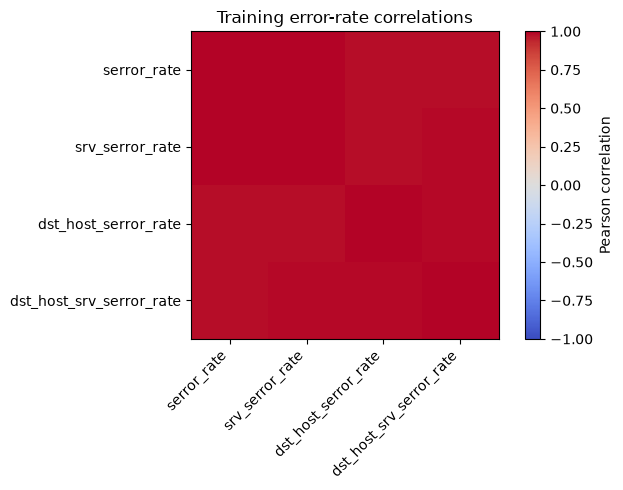

In [ ]:
## 3. Visualize related rates

rates = ['serror_rate', 'srv_serror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate']
corr = train[rates].corr()
plt.figure(figsize=(7, 5))
plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.xticks(range(4), rates, rotation=45, ha='right')
plt.yticks(range(4), rates)
plt.colorbar(label='Pearson correlation')
plt.title('Training error-rate correlations')
plt.tight_layout()
plt.savefig(FIG / '05_correlation.png', dpi=140, bbox_inches='tight')
plt.show()
